# Introduction

---

#  Imports

This section corresponds to the import of all the libraries and modules used in the notebook. Some of these libraries may need to be installed in your Python virtual environment if you haven't done so already.

In [ ]:
from branca.colormap import LinearColormap
import osmnx as ox
import networkx as nx
import geopandas as gpd
import pandas as pd
import numpy as np
import momepy
from shapely import geometry
from shapely.geometry import mapping
from shapely.geometry import Polygon, MultiPolygon, LineString, MultiLineString, MultiPoint, Point, box
from shapely.ops import unary_union
from shapely.ops import split
from shapely.ops import nearest_points
from shapely.strtree import STRtree
from scipy.spatial import cKDTree
from sklearn.neighbors import BallTree
import neatnet
import folium
import json
import branca
import math
from geopy.distance import geodesic
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis
import contextily as ctx
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from branca.element import MacroElement
from jinja2 import Template
from matplotlib.colors import LinearSegmentedColormap, Normalize, to_hex

---

#  Methodology

This section corresponds to all the methodological steps that were taken to measure street functions and classify them into typologies.
It is divided in three main subsections:
1. Data gathering and processing
2. Calculating street functions
3. Classification of streets into typologies

# 1. Data gathering and processing

## 1.1. OpenStreetMap data retrieving

This subsection describes the process of retrieving all the OpenStreetMap (OSM) data that will be used in the subsequent steps of the methodology.

### 1.1.1. Defining the ``study_area`` parameter and retrieving its polygon

The ``study_area`` parameter corresponds to the polygon that will be used as a bounding limit for all the OpenStreetMap data that will be retrieved. This parameter filters the OSM data and only retrieves features that fall within the specified area. The polygon should be defined in a way that it covers the area of interest for the analysis. Before running the tool, to make sure the analysis is being performed for the desired study area, check [Nominatim](https://nominatim.openstreetmap.org/ui/search.html). Enter in the search bar the name of the area you want to analyze and click on "Search". The map will zoom in to the area you searched for. This can be used to check if the polygon corresponds to the study area. If that is the polygon you wish to analyze, then set the text you've entered in [Nominatim](https://nominatim.openstreetmap.org/ui/search.html) as the parameter in the script. The script will then use this parameter to retrieve the OSM data for the specified area.

In [ ]:
study_area = "Município de Lisboa, Portugal"

This snippet will use the ``study_area`` parameter to retrieve the polygon that defines the limits of the study area, and it will be used in the results chapter for better communication of the boundaries of the study area. It converts a place name (the study area) into a GeoDataFrame containing the polygon geometry of that place. The Coordinate Reference System (CRS) of the polygon is set to WGS84 (EPSG:4326).

In [ ]:
study_area_gdf = ox.geocode_to_gdf(study_area)

### 1.1.2. Retrieving the exclusion mask of the study area

This subsection retrieves the exclusion mask of the study area. The exclusion mask will be later used to (potentially, as it's not perfect) ensure that, when the road network is converted into a street centerlines network, it keeps its integrity and does not overlap buildings and other features that delimit the urban corridors. As it can be seen below, the exclusion mask is created by many OSM layers and filtered for many tags in order to retain the features that will present the best results in the output network. It is recommended that the user modifies the exclusion mask layers and tags depending on the context of the study area, however, the ones that were selected should work as a starting point for most contexts.

Firstly, it is defined a custom function that will be used for filtering out the features that are not at ground level, as they are not relevant for this analysis. The function checks if the feature has a ``layer`` tag and if it is equal to 0. If the feature does not have a ``layer`` tag, it is considered to be at ground level, like most OSM features are tagged. The function returns ``True`` for features that are at ground level and ``False`` for those that are not.

In [ ]:
def filter_ground_level(gdf):
    # Ensure 'layer' column exists
    if "layer" not in gdf.columns:
        gdf["layer"] = "0"
    layer_num = pd.to_numeric(gdf["layer"], errors="coerce").fillna(0)
    return gdf[layer_num >= 0]

Then, we define a list of OSM layers and tags that will be used to create the exclusion mask. The layers may include buildings, construction sites, schools, sports pitches, cemeteries, parks, hospitals, among others, depending on how these features were mapped in OSM. Some of these features create noise that make it harder for the simplification algorithm to correctly identify what are actual buildings or areas we might want to keep or just smaller street elements like kiosks or fountains. The tags are used to filter out the features that are not relevant for the exclusion mask.

In [ ]:
# Retrieving buildings
buildings = ox.features_from_place(study_area, tags={"building": True})

# Applying filters to the "building" features
if "building" in buildings.columns:
    buildings = buildings[buildings["building"] != "roof"]
    buildings = buildings[buildings["building"] != "container"]
    buildings = buildings[buildings["building"] != "kiosk"]
    buildings = buildings[buildings["building"] != "memorial"]
    buildings = buildings[buildings["building"] != "service"]
    buildings = buildings[buildings["building"] != "guardhouse"]
    buildings = buildings[buildings["building"] != "train_station"]

if "amenity" in buildings.columns:
    buildings = buildings[buildings["amenity"] != "shelter"]
    buildings = buildings[buildings["amenity"] != "fountain"]
    buildings = buildings[buildings["amenity"] != "toilets"]

if "artwork_type" in buildings.columns:
    buildings = buildings[buildings["artwork_type"] != "statue"]

if "historic" in buildings.columns:
    buildings = buildings[buildings["historic"] != "monument"]
    buildings = buildings[buildings["historic"] != "memorial"]

if "memorial" in buildings.columns:
    buildings = buildings[buildings["memorial"] != "statue"]
    buildings = buildings[buildings["memorial"] != "bust"]

if "shop" in buildings.columns:
    buildings = buildings[buildings["shop"] != "kiosk"]

if "bridge:support" in buildings.columns:
    buildings = buildings[buildings["bridge:support"] != "yes"]
    buildings = buildings[buildings["bridge:support"] != "pier"]
    buildings = buildings[buildings["bridge:support"] != "abutment"]
    buildings = buildings[buildings["bridge:support"] != "lift_pier"]
    buildings = buildings[buildings["bridge:support"] != "pivot_pier"]
    buildings = buildings[buildings["bridge:support"] != "pylon"]
    
# Filtering for ground level features
buildings = filter_ground_level(buildings)

In [ ]:
# Retrieving construction areas
construction = ox.features_from_place(study_area, tags={"landuse": "construction"})

# Filtering for ground level features
construction = filter_ground_level(construction)

In [ ]:
# Retrieving schools
schools = ox.features_from_place(study_area, tags={"amenity": "school"})

# Filtering for ground level features
schools = filter_ground_level(schools)

In [ ]:
# Retrieving pitches
pitches = ox.features_from_place(study_area, tags={"leisure": "pitch"})

# Filtering for ground level features
pitches = filter_ground_level(pitches)

In [ ]:
# Retrieving cemeteries
cemeteries = ox.features_from_place(study_area, tags={"landuse": "cemetery"})

# Filtering for ground level features
cemeteries = filter_ground_level(cemeteries)

After that, the exclusion mask is prepared for geospatial analysis by first reprojecting the several layers into a common coordinate reference system (EPSG:3857)to ensure spatial consistency. EPSG:3857 is different from EPSG:4326 (WGS84) because it uses meters as units, which is more suitable for distance calculations and spatial operations. Then, all the layers are dissolved into a single geometry to create a unified ``exclusion_mask``. This step is crucial to ensure that the exclusion mask accurately represents all the features that need to be considered when simplifying the road network.

In [ ]:
buildings = buildings.to_crs(epsg=3857)
construction = construction.to_crs(epsg=3857)
schools = schools.to_crs(epsg=3857)
pitches = pitches.to_crs(epsg=3857)
cemeteries = cemeteries.to_crs(epsg=3857)

It then extracts and combines the ``geometry`` columns from these layers into a single DataFrame, effectively aggregating all areas that should be protected from simplification. Keeping just the geometry column is important to reduce memory usage and improve performance in subsequent spatial operations.

In [ ]:
exclusion_mask = gpd.GeoDataFrame(
    pd.concat([
       buildings[['geometry']],
       construction[['geometry']],
       schools[['geometry']],
       pitches[['geometry']],
       cemeteries[['geometry']]    
    ], ignore_index = True)
)

### 1.1.3. Retrieving the ``highway`` network of the study area

This subsection retrieves the ``highway`` network of the study area. This network is a representation of the road network in OpenStreetMap, and it includes all types of roads, paths, and other transportation routes.

First, a ``cf`` custom filter is defined in order to call only the relevant ``highway`` features. This filter also removes features that correspond to areas.

In [ ]:
# Filtering out unwanted highway types
cf_highway_types = [
    'motorway', 'motorway_link',
    'trunk', 'trunk_link',
    'primary', 'primary_link',
    'secondary', 'secondary_link',
    'tertiary', 'tertiary_link',
    'residential', 'unclassified',
    'living_street','pedestrian'    
]

cf = '["highway"~"{}"]'.format('|'.join(cf_highway_types))

# Filtering out area highway types
cf += cf + '["area"!~"yes"]'
cf += cf + '["area:highway"!~"footway"]'
cf += cf + '["area:highway"!~"path"]'
cf += cf + '["area:highway"!~"cycleway"]'
cf += cf + '["area:highway"!~"steps"]'
cf += cf + '["area:highway"!~"pedestrian"]'

Then, we call the data from OSM using the ``study_area`` and the custom filter. The ``retain_all`` parameter is set to ``False`` in order to keep the main network brach (discarding isolated segments in the network). The ``simplify`` parameter is set to ``False`` to avoid any simplification of the geometries at this stage, as we want to work with the most detailed representation of the road network possible before any processing.

In [ ]:
network = ox.graph_from_place(
    study_area,
    custom_filter=cf,
    retain_all=False, 
    simplify=False, 
    truncate_by_edge=True
)

The network graph is converted into a GeoDataFrame. This transformation allows for easier manipulation and visualization of spatial data using GeoPandas. In this step, only the edges (representing roads or paths) are extracted, excluding the nodes (intersections or endpoints), as the focus of this work is on linear features.

In [ ]:
network_gdf = ox.graph_to_gdfs(network, nodes=False, edges=True,)

The following step filters out any rows where the geometry is null, which could occur due to incomplete or corrupted data. Removing these ensures that subsequent spatial operations are performed only on valid geometries.

In [ ]:
network_gdf = network_gdf[network_gdf.geometry.notnull()]

When the custom filter was created, it was set to include only the "highway" features that are not "area" types. However, in some cases, OSM data may still contain area geometries that were not filtered out (since the filter was only applied through tags). To address this, the following code checks for any geometries that are of type ``LineString`` or ``MultiLineString`` and keeps only those in the GeoDataFrame. This corresponds to the main filter for linear features, with the tags of OSM being just a small part of the filtering process in order to be more computationally efficient when retrieving the data from the Overpass API.

In [ ]:
network_gdf = network_gdf[network_gdf.geometry.type.isin(['LineString', 'MultiLineString'])]

## 1.2. Deriving a street centerlines network

This subsection corresponds to the creation of a street centerlines network from the ``highway`` network retrieved from OSM in the previous subsection. The street centerlines network is a simplified representation of urban corridors, represented by a line that runs through the center of the street (hence the name) and will be the base on which the street functions will be calculated.

### 1.2.1. Preparing the network for simplification

Since some of the geometries in the road network will be merged to street centerlines, namely in streets that present multiple carriageways, some of the original network information will be lost. With this being said, the next step removes all columns from the GeoDataFrame except for the ``geometry`` column (where the spatial information is kept) and other columns that retain information related to the corridor, such as ``name`` and ``osmid``. This is done to ensure that only the geometries are passed to the ``neatnet.neatify()`` function, which is responsible for deriving the street centerlines.

In [ ]:
network_gdf_essential = network_gdf[['name','osmid','highway','geometry']]

In [ ]:
network_gdf_essential = network_gdf_essential.replace({
        "motorway_link": "motorway",
        "trunk_link": "trunk",
        "primary_link": "primary",
        "secondary_link": "secondary",
        "tertiary_link": "tertiary"
    })

Since the ``neatnet.neatify()`` function is a geoprocessing operation that heavily relies on distances, the geometry column is reprojected to a coordinate reference system (CRS) that uses meters as units. This is done to ensure that the distances are calculated accurately and consistently. The EPSG:3857 CRS is commonly used for web mapping applications and is suitable for this purpose, as mentioned earlier.

In [ ]:
network_gdf_essential_3857 = network_gdf_essential.to_crs(epsg=3857)

In [ ]:
highway_priority = [
    "motorway",
    "trunk",
    "primary",
    "secondary",
    "tertiary",
    "residential",
    "unclassified",
    "living_street",
    "pedestrian"
]

### 1.2.2. Simplifying the network

The ``neatnet.neatify()`` function is then called to derive the street centerlines from the road network. This function simplifies the road network by removing unnecessary details while preserving the overall structure and connectivity of the streets. The result is a simplified representation of the street network, which will be used for the analysis. This function inputs as parameters the network GeoDataFrame only with the ``geometry``, ``name`` and ``osmid`` columns and projected in EPSG:3857, and the exclusion mask that was set earlier. The output is a GeoDataFrame containing the street centerlines (``street_lines``).

In [ ]:
street_lines = neatnet.neatify(network_gdf_essential_3857, exclusion_mask = exclusion_mask.geometry,)

### 1.2.3. Correcting the ``_status`` == ``new`` segments of the output network (probing methodology)

During the process of running ``neatnet.neatify()``, the tool is not able to keep some of the data from the original network, namely the new segments whose ``_status`` column is set to ``new``. This happens because, as hinted earlier, these segments result from a merge of multiple original segments during the simplification process and do not have a direct correspondence to any segment of that original network. As a result, they do not inherit any attributes from the original network, and their attribute values are null. To fix this, the following code "probes" the original network to find the nearest segment to each of the new segments. It then copies the attributes from the nearest segment in the original network to the new segment in the simplified network. This way, the new segments will have meaningful attribute values that are consistent with the original network.

Before starting the probing methodology, we give both the original carriageways (``network_gdf_essential``) and the new streets (``street_lines``) unique identifiers. These IDs (``orig_id`` and ``street_id``) will help us keep track of matches later when exploding geometries or merging attributes. Resetting indices ensures the IDs are consistent and reproducible.

In [ ]:
def assign_ids(gdf, col_name):
    gdf = gdf.reset_index(drop=True).copy()
    gdf[col_name] = gdf.index.astype(str)
    return gdf

network_gdf_essential = assign_ids(network_gdf_essential, 'orig_id')
street_lines = assign_ids(street_lines, 'street_id')

New segments are extracted from the ``street_lines`` GeoDataFrame in order to apply the procedure to just the segments that require and save computing time.

In [ ]:
street_lines_new = street_lines.loc[street_lines['_status'] == 'new', ['street_id', '_status', 'geometry']].copy()
street_lines_new = gpd.GeoDataFrame(street_lines_new, crs=street_lines.crs)

Points are then interpolated every 10 meters, and at each point a perpendicular “probe” is drawn about 100 meters long (50 meters to each side). These probes cut across the full width of the street, ensuring that even very wide boulevards intersect with the relevant original carriageways. This approach keeps the benefits of splitting (granularity for attribute assignment) while allowing probes to be generated smoothly along the entire street.

In [ ]:
probe_half_length = 50   # 50 meters to each side (total 100-meter probe)
probe_spacing     = 10   # probe every 10 meters along the line

# dissolve to one geometry per street_id
dissolved = street_lines_new.dissolve(by='street_id', as_index=False)

probe_recs = []
for _, row in dissolved.iterrows():
    sid  = row.street_id
    geom = row.geometry
    branches = geom.geoms if geom.geom_type == 'MultiLineString' else [geom]
    for seg in branches:
        seg_len = seg.length
        if seg_len <= probe_spacing:
            continue
        dists = np.arange(probe_spacing, seg_len, probe_spacing)

        # unit perpendicular from endpoints
        p0, p1 = Point(seg.coords[0]), Point(seg.coords[-1])
        dx, dy = p1.x - p0.x, p1.y - p0.y
        ux, uy = -dy, dx
        norm   = (ux**2 + uy**2)**0.5
        if norm == 0:
            continue
        ux, uy = ux/norm, uy/norm

        for d in dists:
            mid  = seg.interpolate(d)
            end1 = Point(mid.x + ux*probe_half_length, mid.y + uy*probe_half_length)
            end2 = Point(mid.x - ux*probe_half_length, mid.y - uy*probe_half_length)
            probe_recs.append({'street_id': sid, 'geometry': LineString([end2, end1])})

probes = gpd.GeoDataFrame(probe_recs, crs=street_lines_new.crs)
probes['probe_seq'] = probes.groupby('street_id').cumcount()
probes['probe_id']  = probes['street_id'] + '_' + probes['probe_seq'].astype(str)
probes = probes.drop(columns='probe_seq')

Once the ``probes`` have been generated, the next step is to determine which original carriageway segments they intersect. This is done efficiently by first using a spatial index to identify candidate lines that fall within the bounding box of each probe, which greatly reduces the number of geometries that need to be checked. Only the candidates that truly intersect the probe are retained. This process assigns to every probe a list of one or more ``orig_id`` values corresponding to the carriageways that it touches. In practice, this means that each probe effectively “samples” the original dataset, recording which existing lines are encountered when extending across the width of the new street. The result is a set of probe geometries, each linked to the original lines it intersects, which provides the foundation for inferring attributes.

In [ ]:
probes = probes.to_crs(network_gdf_essential.crs)
sidx   = network_gdf_essential.sindex

orig_ids_list = []
for g in probes.geometry:
    cand_idx = list(sidx.intersection(g.bounds))
    if not cand_idx:
        orig_ids_list.append([])
        continue
    cand = network_gdf_essential.iloc[cand_idx]
    hits = cand[cand.intersects(g)]
    orig_ids_list.append(hits['orig_id'].tolist())

probes['orig_ids'] = orig_ids_list

Because a single probe can intersect multiple original carriageways, the results from the previous step are stored as lists of identifiers. To analyze these in a structured way, the data is “exploded”, meaning that each probe–carriageway combination is written out as its own row in the dataset. This ensures that every intersected line is represented explicitly rather than hidden inside a list. Once exploded, the attributes from the original dataset, such as the ``name`` of the street and its ``osmid`` identifier, can be joined directly to each probe–carriageway combination. At this point, the dataset expresses exactly which probe touched which original line, along with the relevant attributes, making it possible to analyze the probes individually before moving on to aggregation.

In [ ]:
exploded = (
    probes[['probe_id','street_id','geometry','orig_ids']]
    .explode('orig_ids')
    .dropna(subset=['orig_ids'])
    .rename(columns={'orig_ids':'orig_id'})
)

merged = exploded.merge(
    network_gdf_essential.drop(columns='geometry'),
    on='orig_id',
    how='left'
)

Each probe now has potentially several attribute candidates, since it may have intersected more than one original line. To resolve these, a probe-level aggregation is performed. For the ``name`` attribute, the statistical mode (the most frequently occurring value) is selected. If no single name dominates and there is a tie, the tied values are preserved as a list so that no information is lost. For ``osmid``, which can naturally represent multiple carriageways in parallel, the union of all unique identifiers encountered by the probe is retained. This produces a clean, consolidated record for each probe: one geometry that carries either a single attribute value or a structured collection of possible values. By summarizing at the probe level, the dataset becomes easier to interpret and ready for the next stage of aggregation at the street scale.

In [ ]:
def mode_or_tied(vals):
    s = pd.Series(vals).dropna()
    if s.empty:
        return None
    m = s.mode()
    if len(m) == 1:
        return m.iloc[0]
    return m.unique().tolist()

def most_frequent_with_priority(series: pd.Series, priority_order) -> object:
    s = pd.Series(series).dropna()
    if s.empty:
        return np.nan

    counts = s.value_counts()
    top = counts.max()
    candidates = counts[counts == top].index.tolist()

    # Build a priority index: lower index => higher priority
    priority_index = {v: i for i, v in enumerate(priority_order)} if priority_order is not None else {}

    def tie_key(v):
        return (priority_index.get(v, float("inf")), str(v))

    return min(candidates, key=tie_key)

def agg_per_probe(df):
    name_agg  = mode_or_tied(df['name'])
    osmid_agg = pd.unique(df['osmid'].dropna()).tolist()
    highway_agg = most_frequent_with_priority(df['highway'], highway_priority)
    return pd.Series({'name': name_agg, 'osmid': osmid_agg, 'highway': highway_agg})

probe_attrs = merged.groupby('probe_id').apply(agg_per_probe).reset_index()
probes = probes.merge(probe_attrs, on='probe_id', how='left')

C:\Users\Asus\AppData\Local\Temp\ipykernel_9036\2547176583.py:33: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  probe_attrs = merged.groupby('probe_id').apply(agg_per_probe).reset_index()


Probe-level results are combined by ``street_id`` to assign attributes to each new street in a way that is both lightweight and deterministic. For ``name``, a majority rule is applied across all probes belonging to the street. If a single value clearly occurs most often, that value is assigned. If there is a tie for most frequent, the tie is not forced to a single winner, and instead the list of tied names is retained exactly as the set of “most frequent” candidates. This preserves information about local ambiguity without introducing additional computation or heuristics. For ``osmid``, the union of all identifiers observed across the street’s probes is kept by design, since multiple parallel carriageways may legitimately belong to the same street; no further tie-breaking is needed.

In [ ]:
def deterministic_sort(vals):
    # Sort deterministically as strings; works for int/str/object mixtures
    return sorted(vals, key=lambda v: str(v))

records = []

for sid, grp in probes.groupby('street_id'):
    out = {'street_id': sid}

    # ----- name: majority vote; if tie, keep the tied list (sorted) -----
    # Each probe's 'name' may be a scalar or a list, so explode safely.
    name_series = pd.Series(grp['name']).dropna()
    name_series = name_series.explode().dropna()

    if name_series.empty:
        out['name'] = None
    else:
        counts = name_series.value_counts()
        top = counts.max()
        winners = counts[counts == top].index.tolist()
        winners = deterministic_sort(winners)

        # If a single winner, use the scalar; if multiple, keep the sorted list.
        out['name'] = winners[0] if len(winners) == 1 else winners
        
    # ----- highway: majority vote with priority tie-break -----
    hwy_series = pd.Series(grp['highway']).dropna()
    hwy_series = hwy_series.explode().dropna()

    if hwy_series.empty:
        out['highway'] = None
    else:
        out['highway'] = most_frequent_with_priority(hwy_series, highway_priority)


    # ----- osmid: union across probes (sorted, deterministic) -----
    osmid_series = pd.Series(grp['osmid']).dropna()
    osmid_series = osmid_series.explode().dropna()

    if osmid_series.empty:
        out['osmid'] = []
    else:
        uniq_osmids = pd.unique(osmid_series).tolist()
        out['osmid'] = deterministic_sort(uniq_osmids)

    records.append(out)

street_attrs = pd.DataFrame.from_records(records)

The final step is to bring the aggregated attributes back into the main ``street_lines`` dataset. Each ``street_id`` is matched with its inferred values for ``name`` and ``osmid``, and these are merged as new columns. When a segment already has valid attributes, those are kept to avoid overwriting existing information. This ensures that the original integrity of the dataset is preserved while the newly created segments are fully integrated into the network. The result is a corrected street dataset where previously ``_status`` == ``new`` segments now carry meaningful names and identifiers, aligned as closely as possible with the original carriageways.

In [ ]:
street_lines = street_lines.merge(street_attrs, on='street_id', how='left')

for c in ['name','osmid','highway']:
    if f'{c}_x' in street_lines and f'{c}_y' in street_lines:
        street_lines[c] = street_lines[f'{c}_x'].combine_first(street_lines[f'{c}_y'])
        street_lines = street_lines.drop(columns=[f'{c}_x',f'{c}_y'])

Next, we ensure that every street segment has a ``length`` attribute, which is essential for calculating shortest paths in a weighted graph. The length is calculated in meters using the geometry of each street segment.

In [ ]:
if "length" not in street_lines.columns:
    street_lines["length"] = street_lines.geometry.length.astype(float)

# 2. Calculating street functions

## 2.1. Calculating the "link" function

The calculation of the "link" function is very straightforward, corresponding to the betweenness centrality of each street segment in the network. Betweenness centrality is a measure of how often a node or edge appears on the shortest paths between two other nodes in the network. In the context of street networks, a street segment with high betweenness centrality is one that is frequently used as a route between different locations, indicating its (potential) importance as a through movement corridor, and therefore, with a high "link" function.

There is need for preparing the street centerlines network for the calculation of the betweenness centrality. This involves creating a graph representation of the street network in a format that can be processed by the NetworkX library (a GeoDataFrame won't do). The first step is to define the endpoints of each street segment. The ``endpoints()`` function takes a geometry (either a ``LineString`` or a ``MultiLineString``) and returns the start and end coordinates of these elements. This is important because the graph representation requires nodes (intersections or endpoints) and edges (street segments) to be defined.

In [ ]:
def endpoints(geom):
    if isinstance(geom, LineString):
        c = geom.coords
        return [((c[0][0], c[0][1]), (c[-1][0], c[-1][1]))]
    elif isinstance(geom, MultiLineString):
        pairs = []
        for part in geom.geoms:
            c = part.coords
            pairs.append(((c[0][0], c[0][1]), (c[-1][0], c[-1][1])))
        return pairs
    else:
        return []

After that, the NetworkX graph is created (``street_lines_MultiGraph``). Each street segment is added as an edge in the graph, with its endpoints as nodes. The ``street_id`` and ``length`` attributes are included as edge attributes. 

In [ ]:
street_lines_MultiGraph = nx.Graph()
for sid, geom, L in zip(street_lines["street_id"], street_lines.geometry, street_lines["length"]):
    for a, b in endpoints(geom):   # iterate through all pairs
        street_lines_MultiGraph.add_edge(a, b, street_id=sid, length=float(L))

Thus, the edge betweenness centrality is calculated using the ``nx.edge_betweenness_centrality()`` function from the NetworkX library. The ``weight`` parameter is set to ``length``, meaning that the shortest paths will be calculated based on the length of the street segments. The ``normalized`` parameter sets if the betweenness values should correspond to the fraction of all-pairs shortest paths that pass through the edge (``True``) or to the number of all-pairs shortest paths that pass through the edge (``False``).

In [ ]:
edge_bc = nx.edge_betweenness_centrality(street_lines_MultiGraph, 
                                         weight = "length"
                                         )

After that, the edge betweenness centrality that was calculated from the NetworkX graph is mapped back to the original street centerlines GeoDataFrame. For each edge in the graph, it retrieves the ``street_id`` and finds its betweenness centrality score from NetworkX, taking care to handle the fact that undirected edges may be stored as ``(u, v)`` or ``(v, u)``. These values are stored in a dictionary keyed by ``street_id``, which is then used to populate a new ``bet_centrality`` column in the GeoDataFrame. In effect, it ensures every street segment in the dataset carries the centrality measure that was computed on the abstract graph representation.

In [ ]:
id_to_bc = {}

for (u, v, data) in street_lines_MultiGraph.edges(data=True):
    sid = data["street_id"]
    # For an undirected Graph, edge key is (u,v) or (v,u) — use either
    id_to_bc[sid] = edge_bc.get((u, v), edge_bc.get((v, u)))

street_lines["bet_centrality"] = street_lines["street_id"].map(id_to_bc)

Finally, the normalization of the edge betweenness centrality is performed to scale the values between 0 and 1. This is done using 0-max normalization. Unlike min-max normalization, which scales values based on the minimum and maximum values in the dataset, 0-max normalization only considers the maximum value. This means that the lowest value in the dataset will always be 0, and the highest value will be 1, with all other values scaled proportionally in between. This type of normalization was chosen because it preserves the effects the minimum value can have hierarchically. The normalized betweenness centrality values are stored in a new ``LINK`` column, which represents the "link" function of each street segment.

In [ ]:
maxv = np.nanmax(street_lines["bet_centrality"])
street_lines["LINK"] = (street_lines["bet_centrality"] / maxv).clip(0, 1)
# Force all null values in link to become "0"
street_lines["LINK"] = street_lines["LINK"].fillna(0)

## 2.2. Calculating the "place" function

In [ ]:
TAGS = {
    "amenity": [
        "bar","biergarten","cafe","fast_food","food_court","pub","restaurant",
        "college","dancing_school","driving_school","first_aid_school","kindergarten",
        "language_school","library","surf_school","toy_library","research_institute",
        "training","music_school","school","traffic_park","university",
        "bicycle_repair_station","bicycle_wash","car_wash","vehicle_inspection","fuel","taxi",
        "bank","bureau_de_change","money_transfer","payment_centre",
        "clinic","dentist","doctors","hospital","nursing_home","pharmacy","social_facility","veterinary",
        "arts_centre","brothel","casino","cinema","community_centre","conference_centre","events_venue",
        "exhibition_centre","fountain","gambling","love_hotel","music_venue","nightclub","planetarium",
        "social_centre","stage","stripclub","studio","swingerclub","theatre",
        "courthouse","fire_station","police","post_office","townhall",
        "animal_shelter","crematorium","dive_centre","funeral_hall","internet_cafe","marketplace",
        "monastery","mortuary","place_of_worship","public_bath"
    ],
    "shop": True,
    "leisure": True,
    "tourism": True,
    "public_transport": [          # <-- move 'platform' here
        "platform"
    ],
    "highway": [
        "bus_stop"                 # <-- leave only bus_stop here
    ],
    "healthcare": True,
    "religion": True
}

AREA_AS_POLYGON = {
    "leisure": {"park","playground","stadium"}
}


,poi_id,element,amenity_norm,shop_norm,public_transport_norm,railway_norm,highway_norm,geometry
0,0,node,NaN,NaN,stop_position,NaN,NaN,POINT (-1023091.788 4682898.673)
1,1,node,NaN,NaN,stop_position,NaN,NaN,POINT (-1023445.16 4682592.937)
2,2,node,NaN,NaN,NaN,switch,NaN,POINT (-1021572.9 4680617.945)
3,3,node,NaN,NaN,NaN,signal,NaN,POINT (-1021584.077 4680683.029)
4,4,node,NaN,NaN,stop_position,stop,NaN,POINT (-1020424.94 4684523.197)


In [ ]:
# ==== 2.2.A″ — Fetch EXACTLY TAGS, normalize, split areas vs points ====

ox.settings.use_cache = True
ox.settings.log_console = False

# Assumes you already have:
# - street_lines (GeoDataFrame in a metric CRS)
# - study_area (string name used elsewhere in your notebook, e.g., "Município de Lisboa, Portugal")

# 1) Pull POIs by portable keys
POI_KEYS = [
    "amenity", "shop", "tourism", "leisure", "office",
    "healthcare", "public_transport", "railway"
]
poi_tags = {k: True for k in POI_KEYS}

pois_any = ox.features_from_place(study_area, tags=poi_tags)
bus_stop_nodes = ox.features_from_place(study_area, tags={"highway": "bus_stop"})

# Optional: filter out sub-surface features if a 'layer' tag exists
def _filter_ground_level(gdf):
    if "layer" not in gdf.columns:
        return gdf
    layer_num = pd.to_numeric(gdf["layer"], errors="coerce").fillna(0)
    return gdf[layer_num >= 0]

pois_any       = _filter_ground_level(pois_any)
bus_stop_nodes = _filter_ground_level(bus_stop_nodes)

# 2) Merge and project to the CRS of street_lines (meters)
pois_all = pd.concat(
    [pois_any, bus_stop_nodes[~bus_stop_nodes.index.isin(pois_any.index)]],
    axis=0
)
pois_all = gpd.GeoDataFrame(pois_all, geometry="geometry", crs="EPSG:4326").to_crs(street_lines.crs)

# 3) Convert areas/lines to representative points so association is uniform
def _to_point(geom):
    if geom is None or geom.is_empty:
        return None
    if isinstance(geom, Point):
        return geom
    try:
        return geom.representative_point()
    except Exception:
        return None

pois_all["geometry"] = pois_all["geometry"].apply(_to_point)
pois_all = pois_all[pois_all["geometry"].notna()].copy()

# 4) Normalize common OSM columns (handle list-like values)
def _norm(v):
    return v[0] if isinstance(v, list) and len(v) else v

for col in ["amenity","shop","tourism","leisure","office","healthcare","public_transport","railway","highway"]:
    if col in pois_all.columns:
        pois_all[f"{col}_norm"] = pois_all[col].apply(_norm)
    else:
        pois_all[f"{col}_norm"] = np.nan

# 5) Robust POI ID handling for OSMnx (works for MultiIndex or simple Index)
def _build_poi_id(df: gpd.GeoDataFrame) -> gpd.GeoDataFrame:
    df_reset = df.reset_index()

    if {"element", "osmid"}.issubset(df_reset.columns):
        base_id = df_reset["element"].astype(str) + "/" + df_reset["osmid"].astype(str)
    elif {"level_0", "level_1"}.issubset(df_reset.columns):
        base_id = df_reset["level_0"].astype(str) + "/" + df_reset["level_1"].astype(str)
    elif "osmid" in df_reset.columns:
        base_id = df_reset["osmid"].astype(str)
    else:
        # Fallback to positional index if OSM ids aren't available
        base_id = pd.Series(np.arange(len(df_reset)), index=df_reset.index).astype(str)

    df_reset["poi_id"] = base_id
    return gpd.GeoDataFrame(df_reset, geometry="geometry", crs=df.crs)

pois_all = _build_poi_id(pois_all)

# Quick sanity peek
display(pois_all.head()[[
    "poi_id",
    *(["element"] if "element" in pois_all.columns else []),
    *(["osmid"] if "osmid" in pois_all.columns else []),
    "amenity_norm","shop_norm","public_transport_norm","railway_norm","highway_norm","geometry"
]])



In [37]:
# ==== 2.2.B — Variable buffers per segment ====

# Ensure single primary highway value per segment (your aggregation already did this, but be defensive)
def _primary_highway(val):
    if isinstance(val, list) and len(val):
        return val[0]
    return val

street_lines["highway_primary"] = street_lines["highway"].apply(_primary_highway)

# Base radii (meters) — larger for higher hierarchy (your spec)
buffer_by_highway = {
    "motorway": 50.0,
    "trunk": 50.0,
    "primary": 45.0,
    "secondary": 40.0,
    "tertiary": 35.0,
    "residential": 30.0,
    "unclassified": 30.0,
    "pedestrian": 25.0,
    "living_street": 25.0,
}

def _buffer_radius(row):
    base = buffer_by_highway.get(row["highway_primary"], 35.0)
    # bonus for _status == "new"
    return base * (1.15 if row.get("_status") == "new" else 1.0)

street_lines["place_buffer_m"] = street_lines.apply(_buffer_radius, axis=1)

# Build buffers
place_buffers = street_lines[["street_id","highway_primary","_status","place_buffer_m","geometry"]].copy()
place_buffers["geometry"] = place_buffers.geometry.buffer(place_buffers["place_buffer_m"])
place_buffers = gpd.GeoDataFrame(place_buffers, geometry="geometry", crs=street_lines.crs)

# Trigger spatial index (speed-up)
_ = place_buffers.sindex


In [40]:
# ==== 2.2.C — Associate POIs to segments with eligibility rules (no entropy artifacts) ====

# 1) Rough spatial join: POI inside a segment’s buffer
poi_in_buffers = gpd.sjoin(
    pois_all[["poi_id","geometry","amenity_norm","shop_norm","tourism_norm","leisure_norm",
              "office_norm","healthcare_norm","public_transport_norm","railway_norm","highway_norm"]],
    place_buffers[["street_id","highway_primary","_status","place_buffer_m","geometry"]],
    predicate="within",
    how="inner"
).reset_index(drop=True)

# 2) If a POI hits multiple buffers, attach it to the nearest centerline
_seg_geom = street_lines.set_index("street_id")["geometry"].to_dict()

def _dist_to_seg(row):
    geom = _seg_geom.get(row["street_id"])
    return row.geometry.distance(geom) if geom is not None else np.inf

poi_in_buffers["dist_to_seg"] = poi_in_buffers.apply(_dist_to_seg, axis=1)
poi_nearest = (
    poi_in_buffers.sort_values(["poi_id","dist_to_seg"])
                  .groupby("poi_id", as_index=False)
                  .first()
)

# 3) Enforce motorway/trunk rule:
#    - On motorway/trunk: only amenity=fuel and bus stops
#    - Else: accept everything we collected

def _is_bus_stop_like(r):
    if r.get("highway_norm") == "bus_stop":
        return True
    return r.get("public_transport_norm") in {"platform","stop_position"}

def _poi_allowed(hwy_primary, r):
    if hwy_primary in {"motorway","trunk"}:
        if r.get("amenity_norm") == "fuel": return True
        if _is_bus_stop_like(r): return True
        return False
    return True

mask_allowed = poi_nearest.apply(lambda r: _poi_allowed(r["highway_primary"], r), axis=1)
place_poi_attached = poi_nearest.loc[mask_allowed].copy()

# 4) Build a per-street table of POIs (counts only — no groups/entropy)
place_segment_pois = (
    place_poi_attached
    .groupby("street_id")
    .agg(
        place_poi_ids=("poi_id", list),
        place_poi_count=("poi_id", "count")
    )
    .reset_index()
)


# 5) Join back to street_lines (non-destructive + robust)
street_lines = street_lines.merge(place_segment_pois, on="street_id", how="left", validate="one_to_one")

# Ensure columns exist even if right-hand side was empty
if "place_poi_count" not in street_lines.columns:
    street_lines["place_poi_count"] = 0
else:
    street_lines["place_poi_count"] = street_lines["place_poi_count"].fillna(0).astype(int)

if "place_poi_ids" not in street_lines.columns:
    # give each row its own empty list (avoid shared reference)
    street_lines["place_poi_ids"] = [list() for _ in range(len(street_lines))]
else:
    street_lines["place_poi_ids"] = street_lines["place_poi_ids"].apply(lambda v: v if isinstance(v, list) else [])

# Quick sanity: top 10 by raw POI count (will be empty if all zeros)
street_lines.nlargest(10, "place_poi_count")[["street_id","highway_primary","_status","place_poi_count"]]




,street_id,highway_primary,_status,place_poi_count
998,998,primary,changed,105
4767,4767,residential,original,83
5428,5428,residential,original,75
9863,9863,secondary,new,73
1443,1443,residential,changed,72
175,175,residential,changed,71
3959,3959,tertiary,original,66
1410,1410,residential,changed,63
123,123,pedestrian,changed,60
373,373,primary,changed,60


In [41]:
# ==== 2.2.D — Compute PLACE score (PLACE_raw = #POIs × highway factor; PLACE = rank) ====

# 1) POI count
street_lines["n_pois"] = street_lines["place_poi_count"].fillna(0).astype(int)

# 2) Highway adjustment factor (keeps pedestrian/living_street impactful, motorway/trunk damped)
def _highway_factor(h):
    if h == "pedestrian":
        return 1.20
    elif h == "living_street":
        return 1.10
    elif h in {"primary","secondary","tertiary","residential","unclassified"}:
        return 1.0
    elif h in {"motorway","trunk"}:
        return 0.5
    else:
        return 1.0

street_lines["highway_adj"] = street_lines["highway_primary"].apply(_highway_factor)

street_lines["pois_per_100m"] = street_lines.apply(count_pois_per_100m, axis=1)

,street_id,highway_primary,n_pois,highway_adj,PLACE_raw,PLACE
0,0,tertiary,9,1.0,9.0,0.911561
1,1,NaN,1,1.0,1.0,0.500997
2,2,residential,0,1.0,0.0,0.214496
3,3,trunk,0,0.5,0.0,0.214496
4,4,NaN,0,1.0,0.0,0.214496


In [42]:
# --- Global winsorization at the 95th percentile ---
# compute the global 95th percentile across all segments
p99 = street_lines["pois_per_100m"].quantile(0.99)

street_lines[["street_id","highway_primary","n_pois","highway_adj","PLACE_raw","PLACE"]].head()



# 3. Classification of streets into typologies

In [44]:
# --- Absolute classification helper (left-closed, right-open; exact edges go to the upper bin) ---
_eps = np.nextafter(1.0, np.inf)  # slightly above 1.0 so 1.0 is captured in the last bin

abs_bins = [0.0, 0.2, 0.4, 0.6, 0.8, _eps]  # [0,0.2) [0.2,0.4) ... [0.8,1.0]
link_labels = pd.CategoricalDtype(categories=["V", "IV", "III", "II", "I"], ordered=True)
place_labels = pd.CategoricalDtype(categories=["E", "D", "C", "B", "A"], ordered=True)

# Classify LINK and PLACE separately
street_lines["LINK_abs"] = pd.cut(
    street_lines["LINK"],
    bins=abs_bins,
    right=False,                # left-closed, right-open -> boundaries go to the upper bin
    labels=link_labels.categories
).astype(link_labels)

street_lines["PLACE_abs"] = pd.cut(
    street_lines["PLACE"],
    bins=abs_bins,
    right=False,
    labels=place_labels.categories
).astype(place_labels)

# Combine into LP_class_abs (e.g., "IV-C")
street_lines["LP_class_abs"] = street_lines["LINK_abs"].astype(str) + "-" + street_lines["PLACE_abs"].astype(str)

# (Optional) drop the intermediate columns if you don’t want to keep them
# street_lines.drop(columns=["LINK_abs", "PLACE_abs"], inplace=True)

In [45]:
# --- Relative classification using percentile ranks with ties -> upper class ---
# Percentile rank in (0, 1], using method='max' so ties receive the highest rank within the tie group
link_prank = street_lines["LINK"].rank(pct=True, method="max")
place_prank = street_lines["PLACE"].rank(pct=True, method="max")

_eps = np.nextafter(1.0, np.inf)  # ensure rank==1.0 lands in last bin
q_bins = [0.0, 0.2, 0.4, 0.6, 0.8, _eps]  # quintile cutpoints; boundaries go to the upper bin

link_labels = pd.CategoricalDtype(categories=["V", "IV", "III", "II", "I"], ordered=True)
place_labels = pd.CategoricalDtype(categories=["E", "D", "C", "B", "A"], ordered=True)

street_lines["LINK_rel"] = pd.cut(
    link_prank,
    bins=q_bins,
    right=False,  # boundary values (including ties that land exactly on a cut) go to the upper bin
    labels=link_labels.categories
).astype(link_labels)

street_lines["PLACE_rel"] = pd.cut(
    place_prank,
    bins=q_bins,
    right=False,
    labels=place_labels.categories
).astype(place_labels)

# Combine into LP_class_rel (e.g., "IV-C")
street_lines["LP_class_rel"] = street_lines["LINK_rel"].astype(str) + "-" + street_lines["PLACE_rel"].astype(str)

# (Optional) drop the intermediate columns if you don’t want to keep them
# street_lines.drop(columns=["LINK_rel", "PLACE_rel"], inplace=True)


---

#  Results

This section corresponds to the various results that were obtained from the multiple methodologies that were taken in the previous section.

# 4. Base street centerlines network

 The base street centerlines network is the output of the methodological steps taken in section 1.2. It is a simplified representation of urban corridors, represented by a line that runs through the center of the street (hence the name) and will be the base on which the street functions will be calculated. The street centerlines network is a GeoDataFrame that contains, for each segments, OSM attributes such as ``name`` and ``osmid``, as well as a unique identifier for each segment (``street_id``) and a status column (``_status``) that indicates whether the segment was retained from the original network or created as a new segment during the simplification process.

## 4.1. Map

For the proper presentation of the interactive map, the CRS of the used layers was changed to EPSG:4326 (WGS84).

In [46]:
study_area_4326     = study_area_gdf.to_crs(4326)
exclusion_mask_4326 = exclusion_mask.to_crs(4326)
network_4326        = network_gdf_essential.to_crs(4326)
street_lines_4326   = street_lines.to_crs(4326)
probes_4326         = probes.to_crs(4326)

The following code cell creates an interactive map using the Folium library to visualize the street centerlines network along with other relevant layers such as the original road network, the study area boundary, the exclusion mask, and the probes used in the attribute correction process. Each layer is styled differently for better visual distinction, and hover tooltips are added to provide additional information about each feature when hovered over.

In [ ]:
fig, ax = plt.subplots(figsize=(10, 10))

# --- Study area outline ---
study_area_4326.plot(
    ax=ax,
    edgecolor="#000000",
    facecolor="none",
    linewidth=2,
    zorder=3
)

# --- Street lines by status ---
# colors: original (blue), new (green), changed (greenish-blue/teal)
status_colors = {
    "original": "#000AC1",
    "changed": "#00C5C5",
    "new": "#009F03"
}

for status, color in status_colors.items():
    subset = street_lines_4326[street_lines_4326["_status"].str.lower() == status]
    if not subset.empty:
        subset.plot(
            ax=ax,
            edgecolor=color,
            linewidth=1,
            label=status.capitalize(),
            zorder=5
        )


# --- Basemap (kept underneath everything) ---
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, crs=4326, zorder=0)

# --- Legend ---
from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0], [0], color=status_colors["original"], lw=2, label="Original"),
    Line2D([0], [0], color=status_colors["changed"], lw=2, label="Changed"),
    Line2D([0], [0], color=status_colors["new"], lw=2, label="New"),
]

ax.legend(
    handles=legend_handles,
    loc="upper left",
    frameon=True,
    framealpha=0.9
)

ax.set_axis_off()
ax.set_aspect('equal')
plt.tight_layout()
plt.show()


## 4.2. Summary statistics


In [48]:
# Calculate descriptive statistics for the base street centerlines network

# Total number of segments
total_segments = len(street_lines)
# Number of segments by status
status_counts = street_lines["_status"].value_counts()
original_count = status_counts.get("original", 0)
changed_count = status_counts.get("changed", 0)
new_count = status_counts.get("new", 0)

# Percentage by status
original_pct = 100 * original_count / total_segments if total_segments else 0
changed_pct = 100 * changed_count / total_segments if total_segments else 0
new_pct = 100 * new_count / total_segments if total_segments else 0

# Calculate length (in meters) for each segment
if "length" not in street_lines.columns:
    street_lines["length"] = street_lines.geometry.length

# Total network length (km)
total_length_km = street_lines["length"].sum() / 1000
# Length by status (km)
original_length_km = street_lines.loc[street_lines["_status"] == "original", "length"].sum() / 1000
changed_length_km = street_lines.loc[street_lines["_status"] == "changed", "length"].sum() / 1000
new_length_km = street_lines.loc[street_lines["_status"] == "new", "length"].sum() / 1000

# Percentage of length by status
original_length_pct = 100 * original_length_km / total_length_km if total_length_km else 0
changed_length_pct = 100 * changed_length_km / total_length_km if total_length_km else 0
new_length_pct = 100 * new_length_km / total_length_km if total_length_km else 0

# Average segment length (m)
avg_length_m = street_lines["length"].mean()

# Display results

stats_df = pd.DataFrame({
    "Metric": [
        "Number of segments",
        "Original",
        "Changed",
        "New",
        "Network length (km)",
        "Original",
        "Changed",
        "New",
        "Average length of all segments (m)"
    ],
    "Value": [
        total_segments,
        original_count,
        changed_count,
        new_count,
        round(total_length_km, 2),
        round(original_length_km, 2),
        round(changed_length_km, 2),
        round(new_length_km, 2),
        round(avg_length_m, 2)
    ],
    "Percentage (%)": [
        100,
        round(original_pct, 2),
        round(changed_pct, 2),
        round(new_pct, 2),
        100,
        round(original_length_pct, 2),
        round(changed_length_pct, 2),
        round(new_length_pct, 2),
        ""
    ]
})

display(stats_df)

# 5. Street functions results


## 5.1. Results of the "link" function


### 5.1.1. Map


Below is an interactive map that visualizes the "link" function (edge betweenness centrality) of the street segments in the network. The street segments are color-coded based on their "link" function values, with a color gradient ranging from white (low "link" function) to dark red (high "link" function). The map also includes a legend to help interpret the color coding, and tooltips that display the exact "link" function value when hovering over a street segment.

In [ ]:
# Define your custom colors
custom_colors = ['#FFFFFF', "#FF0000", "#000000"]
cmap = LinearSegmentedColormap.from_list('custom_link', custom_colors)
norm = Normalize(vmin=0, vmax=1)

fig, ax = plt.subplots(figsize=(10, 10))

# --- Study area outline ---
study_area_4326.plot(
    ax=ax,
    edgecolor="#000000",
    facecolor="none",
    linewidth=2,
    zorder=5
)

# Plot street segments colored by LINK value
street_lines_4326.plot(
    ax=ax,
    linewidth=1.2,
    zorder=3,
    color=[to_hex(cmap(norm(v))) if not pd.isna(v) else "#cccccc" for v in street_lines_4326["LINK"]]
)

# --- Basemap ---
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, crs=4326, zorder=0)

# --- Colorbar ---
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, fraction=0.03, pad=0.01)

ax.set_axis_off()
ax.set_aspect('equal')
plt.tight_layout()
plt.show()


### 5.1.2. Summary statistics


In [52]:
plt.figure(figsize=(17,4))
plt.hist(street_lines.LINK, 
         bins=200, 
         range=(0, 1), 
         color="#ff0000",
         edgecolor="white",
         linewidth=0.5)
plt.margins(x=0, y=0)
plt.xticks(np.arange(0, 1.1, 0.1))
plt.show()

In [53]:
link_descriptive = street_lines["LINK"].dropna()

# Define the stats
link_stats = {
    "Count": len(link_descriptive),
    "Mean": link_descriptive.mean(),
    "Mode": link_descriptive.mode().iloc[0],
    "Median (P50)": link_descriptive.median(),
    "Standard Deviation": link_descriptive.std(),
    "Q1 (P25)": link_descriptive.quantile(0.25),
    "Q3 (P75)": link_descriptive.quantile(0.75),
    "Interquartile Range (IQR)": link_descriptive.quantile(0.75) - link_descriptive.quantile(0.25),
    "P10": np.percentile(link_descriptive, 10),
    "P90": np.percentile(link_descriptive, 90),
    "P95": np.percentile(link_descriptive, 95),    
    "Skewness": skew(link_descriptive),
    "Kurtosis": kurtosis(link_descriptive)
}

# Put into a DataFrame for nice display
link_stats_df = pd.DataFrame(link_stats, index=["LINK"])
display(link_stats_df.T.round(4))

## 5.2. Results of the "place" function


### 5.2.1. Map


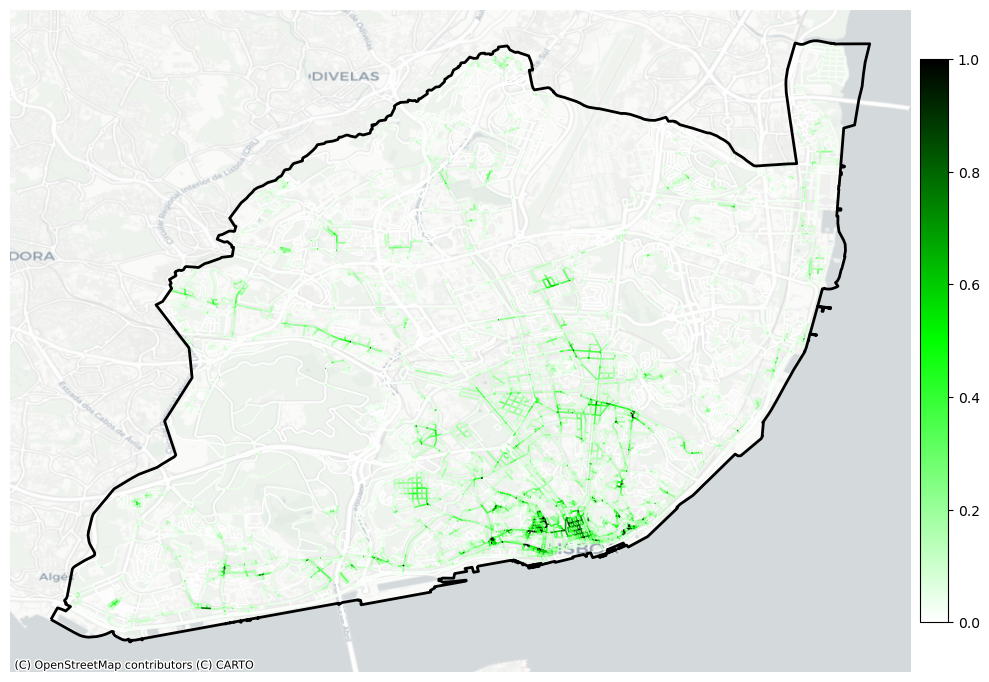

In [54]:
# Define your custom colors
custom_colors = ['#FFFFFF', "#00FF00", "#000000"]
cmap = LinearSegmentedColormap.from_list('custom_PLACE', custom_colors)
norm = Normalize(vmin=0, vmax=1)

import geopandas as gpd
import folium

# 0) Pick your color gradient (matplotlib colormap name)
# Some nice options: "viridis", "plasma", "magma", "inferno", "cividis", "turbo"
cmap_name = "viridis"   # <-- change this to try other gradients

# 1) Ensure needed columns exist
needed_cols = ["street_id","highway_primary","_status","n_pois","highway_adj","PLACE_raw","PLACE","geometry"]
missing = [c for c in needed_cols if c not in street_lines.columns]
if missing:
    raise ValueError(f"street_lines is missing columns: {missing}")

# 2) Convert layers to WGS84 for Folium
streets_place_wgs = street_lines[needed_cols].copy().to_crs(4326)
pois_wgs          = pois_all[["poi_id","amenity_norm","shop_norm","tourism_norm","leisure_norm",
                              "office_norm","healthcare_norm","public_transport_norm","railway_norm",
                              "highway_norm","geometry"]].copy().to_crs(4326)
buffers_wgs       = place_buffers[["street_id","highway_primary","_status","place_buffer_m","geometry"]].copy().to_crs(4326)

# 3) Choose a reasonable center
if "study_area_gdf" in globals() and study_area_gdf is not None and len(study_area_gdf):
    _cent = study_area_gdf.to_crs(4326).unary_union.centroid
    center_latlon = [_cent.y, _cent.x]
else:
    b = streets_place_wgs.total_bounds
    center_latlon = [(b[1]+b[3])/2, (b[0]+b[2])/2]

# 4) Build base map with CartoDB Positron
m = folium.Map(location=center_latlon, zoom_start=12, tiles="CartoDB Positron", control_scale=True)

# 5) PLACE lines layer
m = streets_place_wgs.explore(
    m=m,
    column="PLACE",
    cmap=cmap_name,            # <-- your selectable color gradient
    legend=True,
    tooltip=["street_id","highway_primary","_status","n_pois","highway_adj","PLACE_raw","PLACE"],
    name="PLACE (lines)",
    style_kwds=dict(weight=3, opacity=0.9)
)

# 6) Buffers layer (semi-transparent polygons)
m = buffers_wgs.explore(
    m=m,
    name="Buffers",
    tooltip=["street_id","highway_primary","_status","place_buffer_m"],
    style_kwds=dict(color="#4C78A8", weight=1, fill=True, fillOpacity=0.12)
)

# 7) POI points layer (circle markers)
m = pois_wgs.explore(
    m=m,
    name="POIs",
    color="crimson",
    marker_type="circle",
    marker_kwds=dict(radius=3, fill=True, fillOpacity=0.7),
    tooltip=["poi_id","amenity_norm","shop_norm","tourism_norm","leisure_norm",
             "office_norm","healthcare_norm","public_transport_norm","railway_norm","highway_norm"]
)

# 8) Fit to data bounds & add layer control
if len(streets_place_wgs):
    b = streets_place_wgs.total_bounds
    m.fit_bounds([[b[1], b[0]], [b[3], b[2]]])

folium.LayerControl(collapsed=False).add_to(m)

m



### 5.2.2. Summary statistics


In [55]:
plt.figure(figsize=(17,4))
plt.hist(street_lines.PLACE, 
         bins=200, 
         range=(0, 1), 
         color="#00ff00",
         edgecolor="white",
         linewidth=0.5)
plt.margins(x=0, y=0)
plt.xticks(np.arange(0, 1.1, 0.1))
plt.show()

In [56]:
place_descriptive = street_lines["PLACE"].dropna()

# Define the stats
place_stats = {
    "Count": len(place_descriptive),
    "Mean": place_descriptive.mean(),
    "Mode": place_descriptive.mode().iloc[0],
    "Median (P50)": place_descriptive.median(),
    "Standard Deviation": place_descriptive.std(),
    "Q1 (P25)": place_descriptive.quantile(0.25),
    "Q3 (P75)": place_descriptive.quantile(0.75),
    "Interquartile Range (IQR)": place_descriptive.quantile(0.75) - place_descriptive.quantile(0.25),
    "P10": np.percentile(place_descriptive, 10),
    "P90": np.percentile(place_descriptive, 90),
    "P95": np.percentile(place_descriptive, 95),    
    "Skewness": skew(place_descriptive),
    "Kurtosis": kurtosis(place_descriptive)
}

# Put into a DataFrame for nice display
place_stats_df = pd.DataFrame(place_stats, index=["PLACE"])
display(place_stats_df.T.round(4))

,PLACE
Count,10527.0000
Mean,0.0994
Mode,0.0000
Median (P50),0.0358
Standard Deviation,0.1702
Q1 (P25),0.0000
Q3 (P75),0.1101
Interquartile Range (IQR),0.1101
P10,0.0000
P90,0.2667


# 6. Street typologies results


## 6.1. Map


In [ ]:
street_class_hex = {
    "I-E":   "#ff0000", "I-D":   "#ff4000", "I-C":   "#ff8000", "I-B":   "#ffbf00", "I-A":   "#ffff00",
    "II-E":  "#ff4040", "II-D":  "#ff7040", "II-C":  "#ffb040", "II-B":  "#ffd040", "II-A":  "#dfff40",
    "III-E": "#ff8080", "III-D": "#ff9f60", "III-C": "#ffbf60", "III-B": "#dfff60", "III-A": "#bfff60",
    "IV-E":  "#ffc0a0", "IV-D":  "#ffd080", "IV-C":  "#dfff80", "IV-B":  "#bfff80", "IV-A":  "#80ff80",
    "V-E":   "#ffffff", "V-D":   "#e0ffe0", "V-C":   "#c0ffc0", "V-B":   "#80ff80", "V-A":   "#00ff00"
}

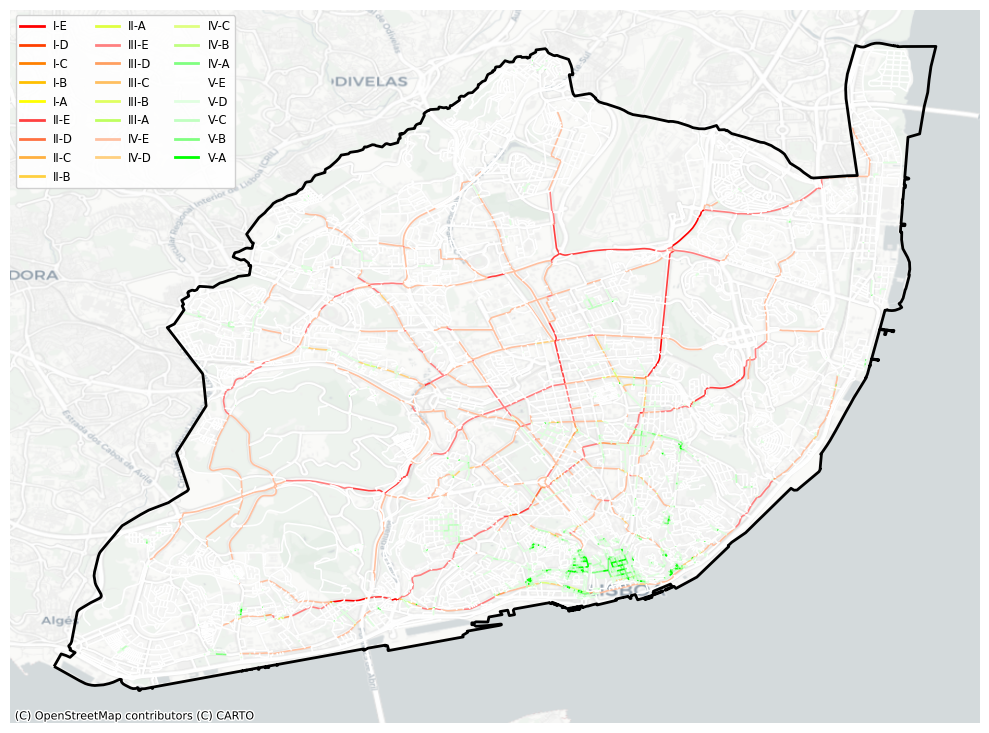

In [64]:
# Map LP_class_abs using street_class_hex colors

fig, ax = plt.subplots(figsize=(10, 10))

# --- Study area outline ---
study_area_4326.plot(
    ax=ax,
    edgecolor="#000000",
    facecolor="none",
    linewidth=2,
    zorder=5
)

# Plot street segments colored by LP_class_abs
for lp_class, color in street_class_hex.items():
    subset = street_lines_4326[street_lines_4326["LP_class_abs"] == lp_class]
    if not subset.empty:
        subset.plot(
            ax=ax,
            linewidth=1.2,
            color=color,
            label=lp_class,
            zorder=3
        )

# --- Basemap ---
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, crs=4326, zorder=0)

# --- Legend ---
legend_handles = [
    Line2D([0], [0], color=color, lw=2, label=lp_class)
    for lp_class, color in street_class_hex.items()
]
ax.legend(
    handles=legend_handles,
    loc="upper left",
    frameon=True,
    framealpha=0.9,
    ncol=3,
    fontsize="small"
)

ax.set_axis_off()
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

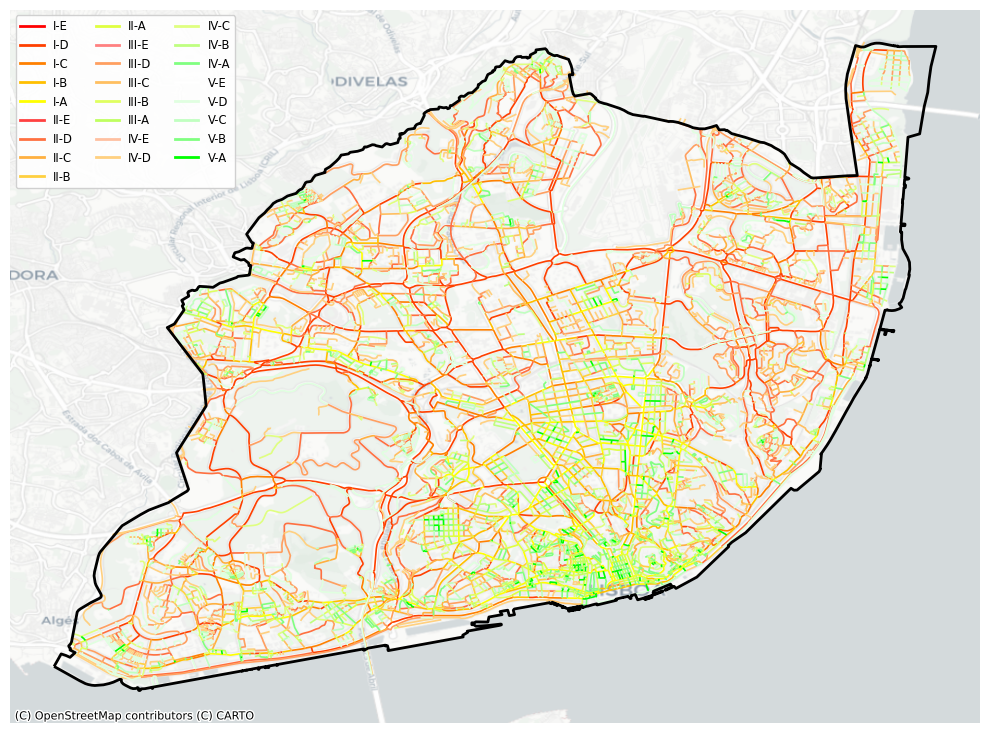

In [65]:
# Map LP_class_rel using street_class_hex colors

fig, ax = plt.subplots(figsize=(10, 10))

# --- Study area outline ---
study_area_4326.plot(
    ax=ax,
    edgecolor="#000000",
    facecolor="none",
    linewidth=2,
    zorder=5
)

# Plot street segments colored by LP_class_rel
for lp_class, color in street_class_hex.items():
    subset = street_lines_4326[street_lines_4326["LP_class_rel"] == lp_class]
    if not subset.empty:
        subset.plot(
            ax=ax,
            linewidth=1.2,
            color=color,
            label=lp_class,
            zorder=3
        )

# --- Basemap ---
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, crs=4326, zorder=0)

# --- Legend ---
legend_handles = [
    Line2D([0], [0], color=color, lw=2, label=lp_class)
    for lp_class, color in street_class_hex.items()
]
ax.legend(
    handles=legend_handles,
    loc="upper left",
    frameon=True,
    framealpha=0.9,
    ncol=3,
    fontsize="small"
)

ax.set_axis_off()
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

## 6.2. Summary statistics

C:\Users\Asus\AppData\Local\Temp\ipykernel_9036\3861955027.py:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


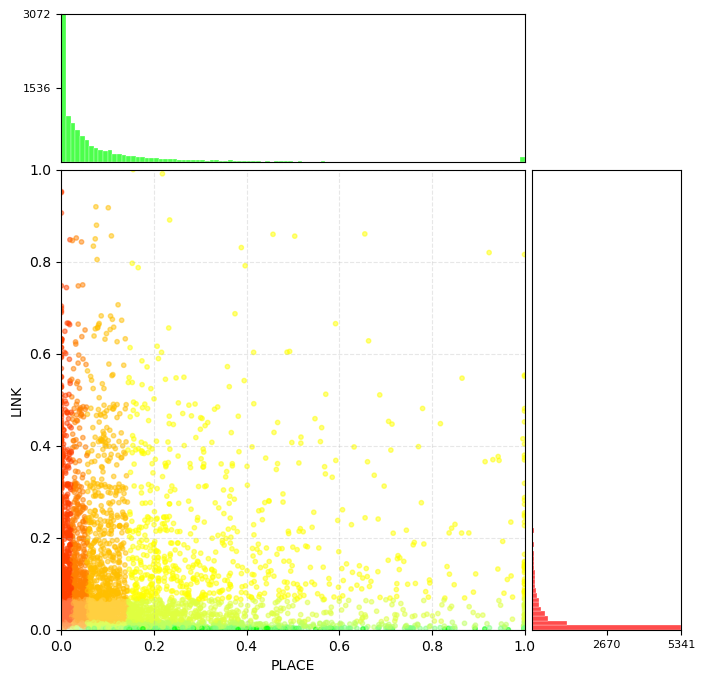

In [72]:
# Example data — replace with your own columns
x = street_lines["PLACE"]
y = street_lines["LINK"]

# Define figure and grid
fig = plt.figure(figsize=(8, 8))
gs = fig.add_gridspec(4, 4, wspace=0.05, hspace=0.05)

# === Main scatter plot ===
ax = fig.add_subplot(gs[1:4, 0:3])
# Map LP_class_rel to colors using street_class_hex
point_colors = street_lines["LP_class_rel"].map(street_class_hex).fillna("#cccccc")
ax.scatter(x, y, alpha=0.5, s=10, color=point_colors)
ax.set_xlabel("PLACE")
ax.set_ylabel("LINK")
ax.grid(True, linestyle='--', alpha=0.3)

# === Top histogram (x) ===
ax_histx = fig.add_subplot(gs[0, 0:3], sharex=ax)
counts_x, bins_x, patches_x = ax_histx.hist(
    x,
    bins=100,
    color='#00ff00',
    alpha=0.7,
    edgecolor='white',
    linewidth=0.3
)
# Hide x-scale (shared with scatter), keep frequency scale
ax_histx.tick_params(axis='x', labelbottom=False, bottom=False)

# Make the tallest bin touch the ceiling: max bin == axis max
max_count_x = counts_x.max()
ax_histx.set_ylim(0, max_count_x)

# Show only half and max of the window (no 0)
ax_histx.set_yticks([max_count_x / 2, max_count_x])
ax_histx.tick_params(axis='y', direction='out', pad=4, labelsize=8)

# === Right histogram (y) ===
ax_histy = fig.add_subplot(gs[1:4, 3], sharey=ax)
counts_y, bins_y, patches_y = ax_histy.hist(
    y,
    bins=100,
    orientation='horizontal',
    color='#ff0000',
    alpha=0.7,
    edgecolor='white',
    linewidth=0.3
)
# Hide y-scale (shared with scatter), keep frequency scale
ax_histy.tick_params(axis='y', labelleft=False, left=False)

# Make the tallest bin touch the ceiling: max bin == axis max
max_count_y = counts_y.max()
ax_histy.set_xlim(0, max_count_y)

# Show only half and max of the window (no 0)
ax_histy.set_xticks([max_count_y / 2, max_count_y])
ax_histy.tick_params(axis='x', direction='out', pad=4, labelsize=8)

# === Layout adjustments ===
ax.margins(x=0, y=0)
plt.tight_layout()
plt.show()


# 7. Dynamic report

In [75]:
# ======================
# 7) Interactive Folium map (mutually-exclusive analyses + dynamic legends)
# ======================
import folium
import geopandas as gpd
import numpy as np
import pandas as pd
import branca
from branca.element import MacroElement, Template

# REQUIREMENT: `street_lines` must exist already (EPSG:4326, with the columns listed in the analysis).
assert "street_lines" in globals(), "Run earlier cells to create `street_lines` before this section."
if street_lines.crs and str(street_lines.crs).lower().endswith("4326") is False:
    street_lines = street_lines.to_crs(epsg=4326)

# Center
centroid = street_lines.unary_union.centroid
LP_report = folium.Map(location=[centroid.y, centroid.x], zoom_start=13, tiles='CartoDB positron', control_scale=True)

# ---- Helpers ----
def _gj_with_tooltip(gdf, key_field, layer_name, style_fn, aliases=None):
    aliases = aliases or {key_field:key_field, "name":"name", "street_id":"street_id"}
    gj = folium.GeoJson(
        gdf,
        name=layer_name,
        style_function=style_fn,
        highlight_function=lambda f: {"weight": 4},
        tooltip=folium.GeoJsonTooltip(
            fields=[key_field, "name", "street_id"],
            aliases=[aliases[key_field], aliases["name"], aliases["street_id"]],
            sticky=True, localize=True
        )
    )
    return gj

# ---- (1) _status ----
status_colors = {"original":"#000AC1", "changed":"#00C5C5", "new":"#009F03"}
def style_status(f):
    return {"color": status_colors.get(f["properties"].get("_status"), "#444444"), "weight": 3, "opacity": 0.9}
fg_status = folium.FeatureGroup(name="(1) Status (_status)", overlay=True, control=True, show=True)
_gj1 = _gj_with_tooltip(street_lines, "_status", "(1) Status (_status)", style_status)
_gj1.add_to(fg_status); fg_status.add_to(LP_report)

legend_status = '''
<div id="legend-status" class="map-legend" style="position: fixed; bottom: 20px; left: 20px; z-index: 9999;
 background: white; padding: 10px 12px; border: 1px solid #bbb; border-radius: 4px; box-shadow: 0 1px 4px rgba(0,0,0,0.3);">
  <div style="font-weight: 600; margin-bottom: 6px;">Status</div>
  <div><span style="display:inline-block;width:14px;height:14px;background:#000AC1;margin-right:6px;border:1px solid #999;"></span>original</div>
  <div><span style="display:inline-block;width:14px;height:14px;background:#00C5C5;margin-right:6px;border:1px solid #999;"></span>changed</div>
  <div><span style="display:inline-block;width:14px;height:14px;background:#009F03;margin-right:6px;border:1px solid #999;"></span>new</div>
</div>
'''
LP_report.get_root().html.add_child(folium.Element(legend_status))

# ---- (2) LINK (0..1) ----
cmap_link = branca.colormap.linear.YlOrRd_09.scale(0, 1).to_step(10)
def style_link(f): return {"color": cmap_link(f["properties"].get("LINK", 0)), "weight": 3, "opacity": 0.9}
fg_link = folium.FeatureGroup(name="(2) Link Analysis (LINK)", overlay=True, control=True, show=False)
_gj2 = _gj_with_tooltip(street_lines, "LINK", "(2) Link Analysis (LINK)", style_link,
                        aliases={"LINK":"LINK", "name":"name", "street_id":"street_id"})
_gj2.add_to(fg_link); fg_link.add_to(LP_report)
legend_link = f'''
<div id="legend-link" class="map-legend" style="display:none; position: fixed; bottom: 20px; left: 20px; z-index: 9999;
 background: white; padding: 10px 12px; border: 1px solid #bbb; border-radius: 4px; box-shadow: 0 1px 4px rgba(0,0,0,0.3);">
  <div style="font-weight:600; margin-bottom:6px;">LINK (0–1)</div>
  {cmap_link._repr_html_()}
</div>
'''
LP_report.get_root().html.add_child(folium.Element(legend_link))

# ---- (3) PLACE (0..1) ----
cmap_place = branca.colormap.linear.BuGn_09.scale(0, 1).to_step(10)
def style_place(f): return {"color": cmap_place(f["properties"].get("PLACE", 0)), "weight": 3, "opacity": 0.9}
fg_place = folium.FeatureGroup(name="(3) Place Analysis (PLACE)", overlay=True, control=True, show=False)
_gj3 = _gj_with_tooltip(street_lines, "PLACE", "(3) Place Analysis (PLACE)", style_place,
                        aliases={"PLACE":"PLACE", "name":"name", "street_id":"street_id"})
_gj3.add_to(fg_place); fg_place.add_to(LP_report)
legend_place = f'''
<div id="legend-place" class="map-legend" style="display:none; position: fixed; bottom: 20px; left: 20px; z-index: 9999;
 background: white; padding: 10px 12px; border: 1px solid #bbb; border-radius: 4px; box-shadow: 0 1px 4px rgba(0,0,0,0.3);">
  <div style="font-weight:600; margin-bottom:6px;">PLACE (0–1)</div>
  {cmap_place._repr_html_()}
</div>
'''
LP_report.get_root().html.add_child(folium.Element(legend_place))

# ---- (4) LP_class_abs ----
if "street_class_hex" in globals():
    street_class_hex_local = street_class_hex
else:
    street_class_hex_local = {
        "I-E": "#ff0000", "I-D": "#ff4000", "I-C": "#ff8000", "I-B": "#ffbf00", "I-A": "#ffff66",
        "II-E": "#ff5c5c", "II-D": "#ff7a4d", "II-C": "#ffb84d", "II-B": "#fff04d", "II-A": "#c0e64d",
        "III-E": "#ff9999", "III-D": "#ffb266", "III-C": "#ffd27a", "III-B": "#c8ef7a", "III-A": "#a1ef7a",
        "IV-E": "#ffd9c2", "IV-D": "#ffe0a6", "IV-C": "#e9ffa6", "IV-B": "#b9ffa6", "IV-A": "#8fff8f",
        "V-E": "#fff7e6", "V-D": "#e6ffe6", "V-C": "#c6ffc6", "V-B": "#8fff8f", "V-A": "#00ff00"
    }

def style_abs(f):
    return {"color": street_class_hex_local.get(f["properties"].get("LP_class_abs"), "#444444"), "weight": 3, "opacity": 0.95}
fg_abs = folium.FeatureGroup(name="(4) LP_class_abs", overlay=True, control=True, show=False)
_gj4 = _gj_with_tooltip(street_lines, "LP_class_abs", "(4) LP_class_abs", style_abs,
                        aliases={"LP_class_abs":"LP_class_abs", "name":"name", "street_id":"street_id"})
_gj4.add_to(fg_abs); fg_abs.add_to(LP_report)

def _make_lp_grid_div(div_id, title):
    link_rows = ["I","II","III","IV","V"]
    place_cols = ["E","D","C","B","A"]
    cells = ""
    for link in link_rows:
        cells += "<div class='row'>"
        for place in place_cols:
            key = f"{link}-{place}"
            color = street_class_hex_local.get(key, "#ffffff")
            cells += f"<div class='cell' title='{key}' style='background:{color};'>{key}</div>"
        cells += "</div>"
    grid_html = f"""
    <div id="{div_id}" class="map-legend" style="display:none; position: fixed; bottom: 20px; left: 20px; z-index: 9999;
     background: white; padding: 10px 12px; border: 1px solid #bbb; border-radius: 4px; box-shadow: 0 1px 4px rgba(0,0,0,0.3);">
      <div style="font-weight:600; margin-bottom:6px;">{title}</div>
      <div class="grid" style="display:flex; flex-direction:column; gap:4px;">
        {cells}
      </div>
    </div>
    <style>
    .map-legend .row {{ display:flex; gap:4px; }}
    .map-legend .cell {{
        width: 46px; height: 32px; line-height: 32px;
        text-align: center; font-size: 12px; font-weight:600; color: #122033;
        border: 1px solid rgba(0,0,0,0.15); border-radius: 2px;
    }}
    </style>
    """
    return grid_html

LP_report.get_root().html.add_child(folium.Element(_make_lp_grid_div("legend-abs", "LP_class_abs (I–V × E–A)")))

# ---- (5) LP_class_rel ----
def style_rel(f):
    return {"color": street_class_hex_local.get(f["properties"].get("LP_class_rel"), "#444444"), "weight": 3, "opacity": 0.95}
fg_rel = folium.FeatureGroup(name="(5) LP_class_rel", overlay=True, control=True, show=False)
_gj5 = _gj_with_tooltip(street_lines, "LP_class_rel", "(5) LP_class_rel", style_rel,
                        aliases={"LP_class_rel":"LP_class_rel", "name":"name", "street_id":"street_id"})
_gj5.add_to(fg_rel); fg_rel.add_to(LP_report)
LP_report.get_root().html.add_child(folium.Element(_make_lp_grid_div("legend-rel", "LP_class_rel (I–V × E–A)")))

# ---- Layer control + exclusivity + dynamic legend ----
folium.LayerControl(collapsed=False).add_to(LP_report)

exclusive_layer_names = [
    "(1) Status (_status)",
    "(2) Link Analysis (LINK)",
    "(3) Place Analysis (PLACE)",
    "(4) LP_class_abs",
    "(5) LP_class_rel",
]
toggle_js = f"""
<script>
var map = this;
function showLegend(name) {{
    var ids = ["legend-status","legend-link","legend-place","legend-abs","legend-rel"];
    ids.forEach(function(id) {{ var el = document.getElementById(id); if (el) el.style.display = "none"; }});
    if (name === "(1) Status (_status)") document.getElementById("legend-status").style.display = "block";
    if (name === "(2) Link Analysis (LINK)") document.getElementById("legend-link").style.display = "block";
    if (name === "(3) Place Analysis (PLACE)") document.getElementById("legend-place").style.display = "block";
    if (name === "(4) LP_class_abs") document.getElementById("legend-abs").style.display = "block";
    if (name === "(5) LP_class_rel") document.getElementById("legend-rel").style.display = "block";
}}
function turnOffOthers(addedName) {{
    var names = {exclusive_layer_names};
    map.eachLayer(function (layer) {{
        if (layer && layer.options && layer.options.name) {{
            var nm = layer.options.name;
            if (names.indexOf(nm) !== -1 && nm !== addedName) {{
                if (map.hasLayer(layer)) map.removeLayer(layer);
            }}
        }}
    }});
}}
map.on('overlayadd', function(e) {{
    var name = e.layer.options.name || "";
    if ({exclusive_layer_names}.indexOf(name) !== -1) {{
        turnOffOthers(name);
        showLegend(name);
    }}
}});
map.on('overlayremove', function(e) {{
    var name = e.layer.options.name || "";
    if ({exclusive_layer_names}.indexOf(name) !== -1) showLegend("");
}});
showLegend("(1) Status (_status)");
</script>
"""
LP_report.get_root().html.add_child(folium.Element(toggle_js))

LP_report.save("Link_Place_Report.html")

C:\Users\Asus\AppData\Local\Temp\ipykernel_9036\612070580.py:17: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  centroid = street_lines.unary_union.centroid
